# Feature Engineering — Customer Segmentation

**Goal:** Transform raw transactions into RFM features ready for clustering.

### Sections
1. Setup & Load Clean Data
2. Compute RFM Features
3. RFM Distribution Analysis
4. Log Transformation
5. RFM Scoring
6. Scale Features
7. Save Processed Data

---
## 1. Setup & Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os, sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

BLUE   = '#2563eb'
GREEN  = '#059669'
ORANGE = '#d97706'
RED    = '#dc2626'
PURPLE = '#7c3aed'

In [2]:
# Load and clean raw data
df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='unicode_escape')

# Rename Customer ID if needed
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

# Clean
df = df[
    df['CustomerID'].notna() &
    ~df['Invoice'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
].copy()

df.drop_duplicates(inplace=True)
df['CustomerID']  = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue']     = df['Quantity'] * df['Price']

print(f'Clean data shape: {df.shape}')
print(f'Unique customers: {df["CustomerID"].nunique():,}')
print(f'Date range: {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')

Clean data shape: (779425, 9)
Unique customers: 5,878
Date range: 2009-12-01 to 2011-12-09


---
## 2. Compute RFM Features

RFM is computed per customer:
- **Recency:**  days since last purchase (lower = more recent = better)
- **Frequency:** number of unique invoices (higher = more loyal)
- **Monetary:**  total revenue generated (higher = more valuable)

In [3]:
# Snapshot date = 1 day after last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\nRFM shape: {rfm.shape}')
print('\n=== RFM Summary ===')
rfm[['Recency','Frequency','Monetary']].describe().round(2)

Snapshot date: 2011-12-10

RFM shape: (5878, 4)

=== RFM Summary ===


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


---
## 3. RFM Distribution Analysis

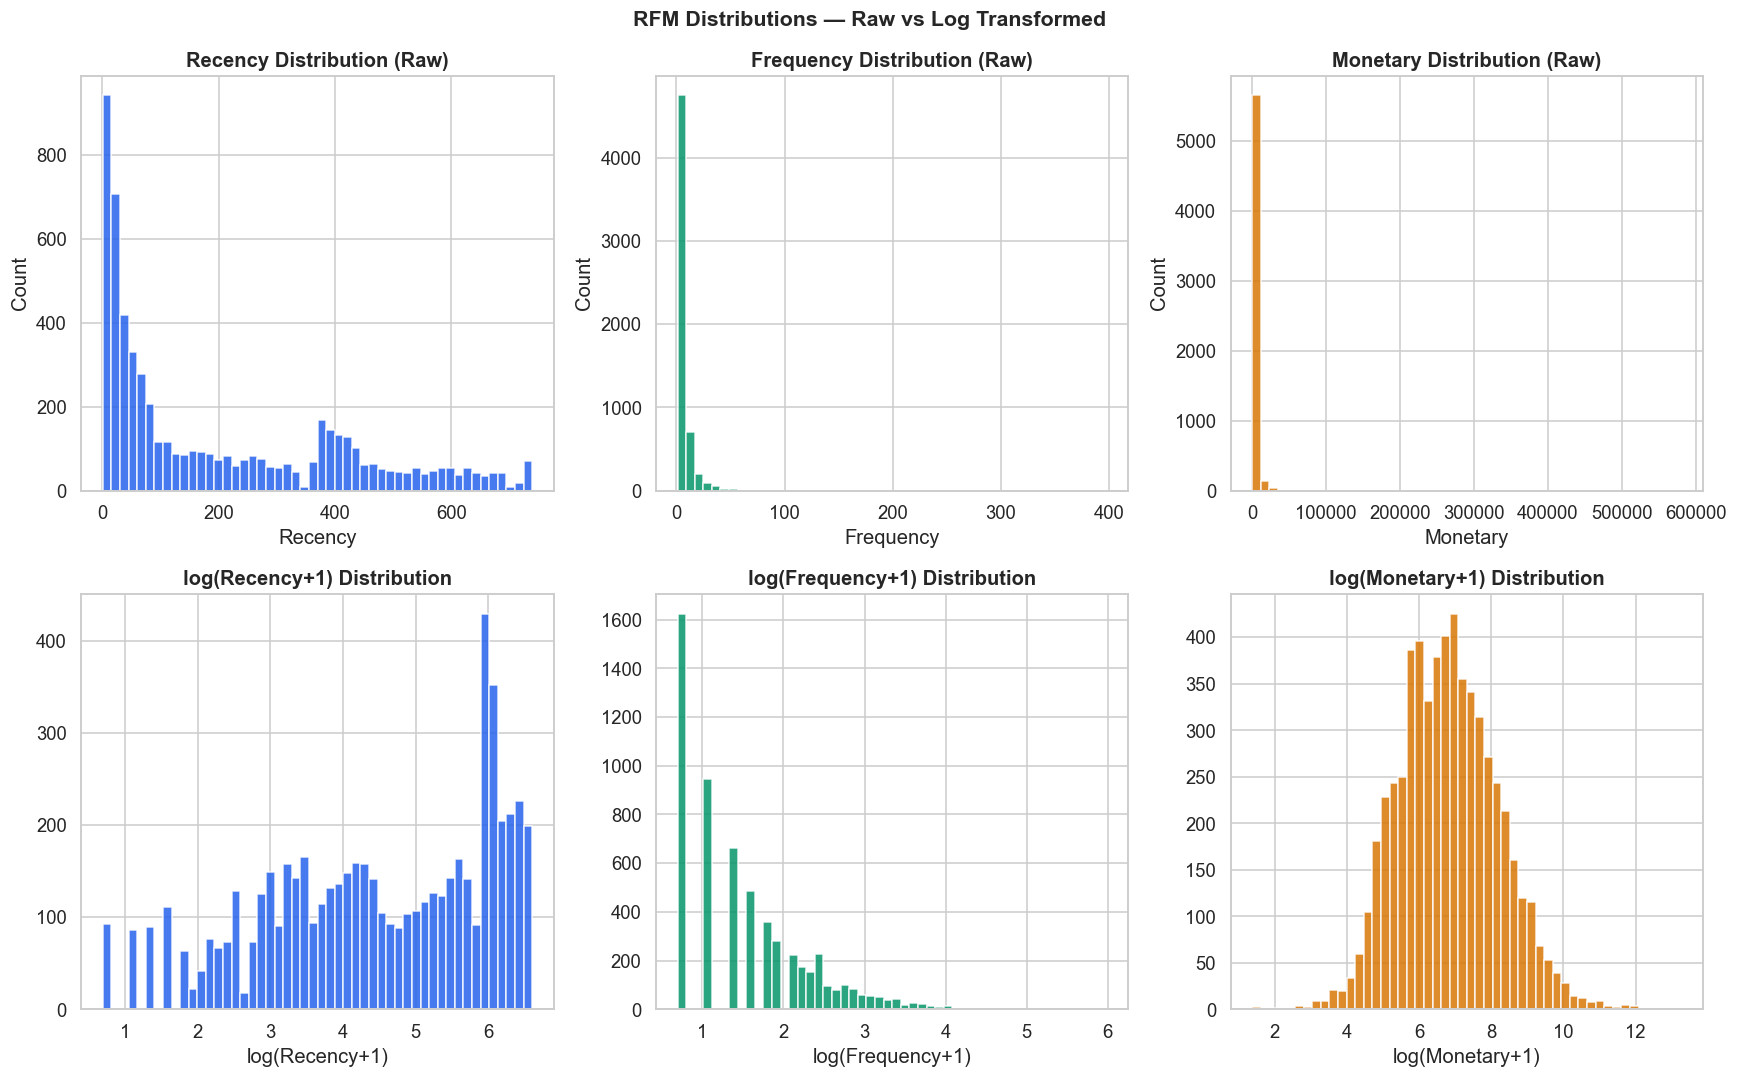

Observation: All three features are heavily right-skewed.
Log transformation significantly reduces skewness.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Raw distributions
for i, (col, color) in enumerate([
    ('Recency',   BLUE),
    ('Frequency', GREEN),
    ('Monetary',  ORANGE)
]):
    rfm[col].hist(bins=50, ax=axes[0,i], color=color, alpha=0.85)
    axes[0,i].set_title(f'{col} Distribution (Raw)', fontweight='bold')
    axes[0,i].set_xlabel(col)
    axes[0,i].set_ylabel('Count')

# Log distributions
for i, (col, color) in enumerate([
    ('Recency',   BLUE),
    ('Frequency', GREEN),
    ('Monetary',  ORANGE)
]):
    np.log1p(rfm[col]).hist(bins=50, ax=axes[1,i], color=color, alpha=0.85)
    axes[1,i].set_title(f'log({col}+1) Distribution', fontweight='bold')
    axes[1,i].set_xlabel(f'log({col}+1)')

plt.suptitle('RFM Distributions — Raw vs Log Transformed',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: All three features are heavily right-skewed.')
print('Log transformation significantly reduces skewness.')

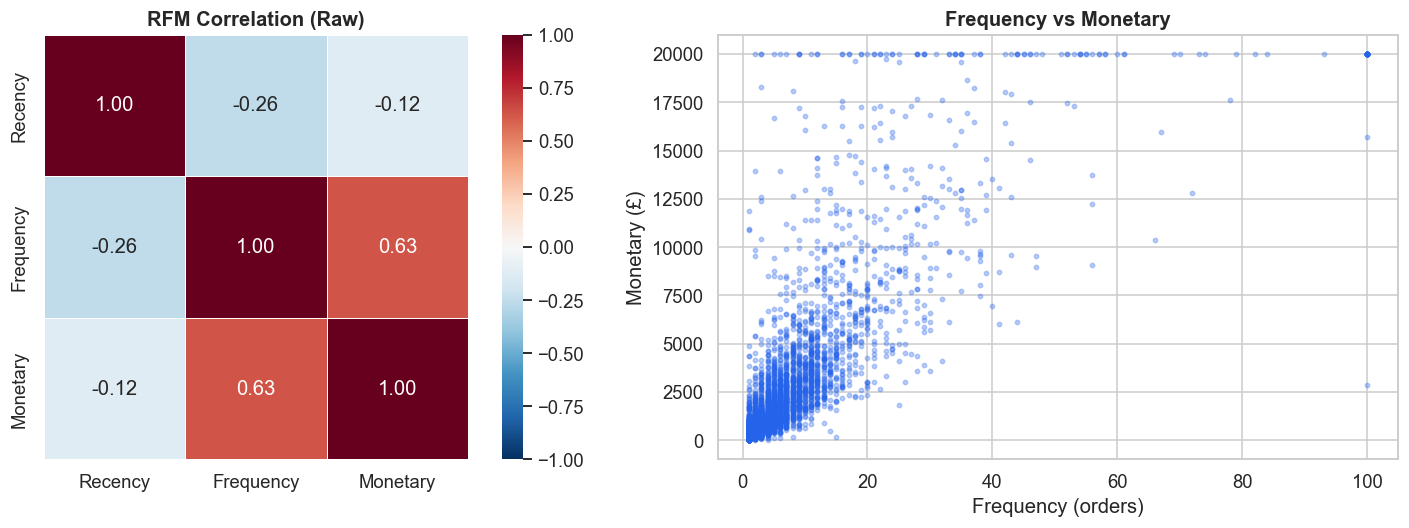

In [5]:
# Correlation between RFM features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw correlation
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r',
            ax=axes[0], linewidths=0.5, square=True,
            vmin=-1, vmax=1)
axes[0].set_title('RFM Correlation (Raw)', fontweight='bold')

# Scatter: Frequency vs Monetary
axes[1].scatter(
    rfm['Frequency'].clip(0, 100),
    rfm['Monetary'].clip(0, 20000),
    alpha=0.3, s=8, color=BLUE
)
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')

plt.tight_layout()
plt.show()

---
## 4. Log Transformation

In [6]:
# Apply log transformation
rfm['log_Recency']   = np.log1p(rfm['Recency'])
rfm['log_Frequency'] = np.log1p(rfm['Frequency'])
rfm['log_Monetary']  = np.log1p(rfm['Monetary'])

# Check skewness before and after
print('=== Skewness Comparison ===')
for col in ['Recency', 'Frequency', 'Monetary']:
    raw_skew = rfm[col].skew()
    log_skew = rfm[f'log_{col}'].skew()
    print(f'{col:12s}: Raw={raw_skew:+.3f} | Log={log_skew:+.3f}')

print('\nValues closer to 0 indicate less skewness.')

=== Skewness Comparison ===
Recency     : Raw=+0.887 | Log=-0.489
Frequency   : Raw=+12.640 | Log=+1.001
Monetary    : Raw=+25.070 | Log=+0.269

Values closer to 0 indicate less skewness.


---
## 5. RFM Scoring

Assign scores 1-4 to each RFM dimension based on quartiles.
Higher score = better on that dimension.
Note: Recency is reversed — lower days = higher score.

=== RFM Score Distribution ===
3     734
4     781
5     732
6     751
7     681
8     533
9     538
10    494
11    634
Name: RFM_Score, dtype: int64


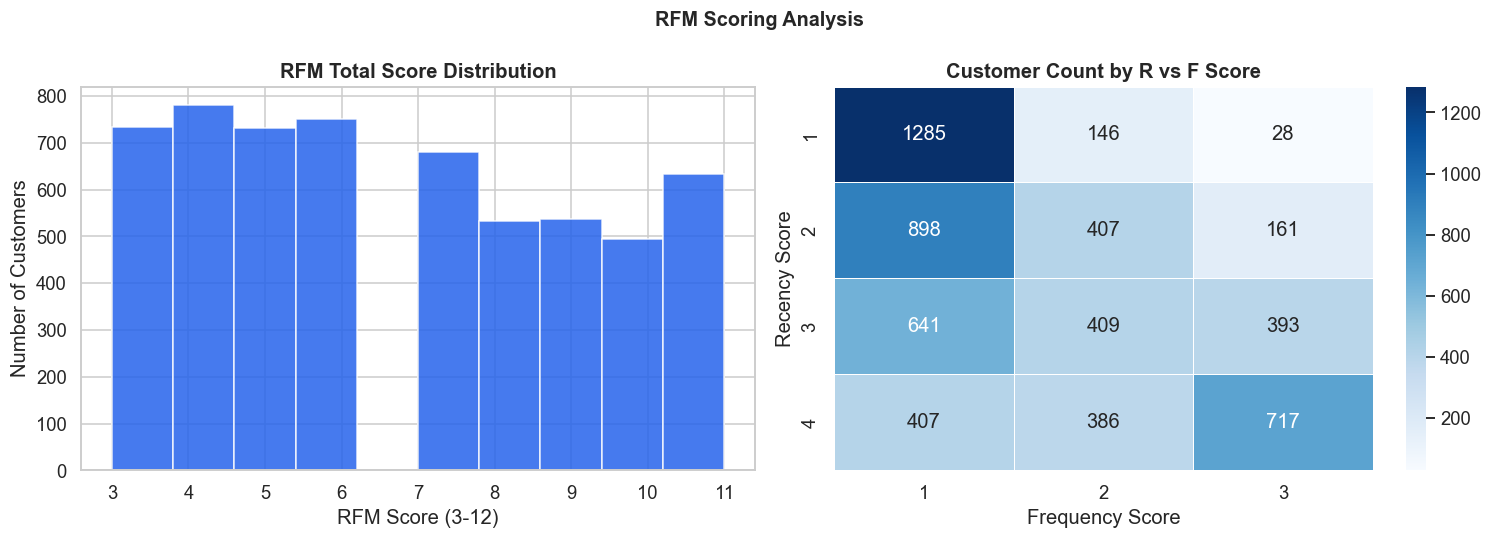

In [13]:
BINS = 4

def safe_qcut(series, bins, ascending=True):
    cut, bin_edges = pd.qcut(series, q=bins, retbins=True, duplicates='drop')
    n_bins = len(bin_edges) - 1
    if ascending:
        labels = list(range(1, n_bins + 1))
    else:
        labels = list(range(n_bins, 0, -1))
    # Use pd.cut with the actual bin edges instead of pd.qcut
    return pd.cut(series, bins=bin_edges, labels=labels,
                  include_lowest=True, duplicates='drop').astype(int)

rfm['R_Score'] = safe_qcut(rfm['Recency'],   BINS, ascending=False)
rfm['F_Score'] = safe_qcut(rfm['Frequency'], BINS, ascending=True)
rfm['M_Score'] = safe_qcut(rfm['Monetary'],  BINS, ascending=True)

rfm['RFM_Score']   = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + \
                      rfm['F_Score'].astype(str) + \
                      rfm['M_Score'].astype(str)

print('=== RFM Score Distribution ===')
print(rfm['RFM_Score'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rfm['RFM_Score'].hist(bins=10, ax=axes[0], color=BLUE, alpha=0.85)
axes[0].set_title('RFM Total Score Distribution', fontweight='bold')
axes[0].set_xlabel('RFM Score (3-12)')
axes[0].set_ylabel('Number of Customers')

# Score heatmap R vs F
pivot = rfm.groupby(['R_Score','F_Score'])['CustomerID'].count().unstack()
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Customer Count by R vs F Score', fontweight='bold')
axes[1].set_xlabel('Frequency Score')
axes[1].set_ylabel('Recency Score')

plt.suptitle('RFM Scoring Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== RFM Segment Counts ===
Lost Customers         1459
Champions              1103
New Customers          1048
At-Risk Customers       898
Loyal Customers         802
Potential Loyalists     568
Name: RFM_Label, dtype: int64


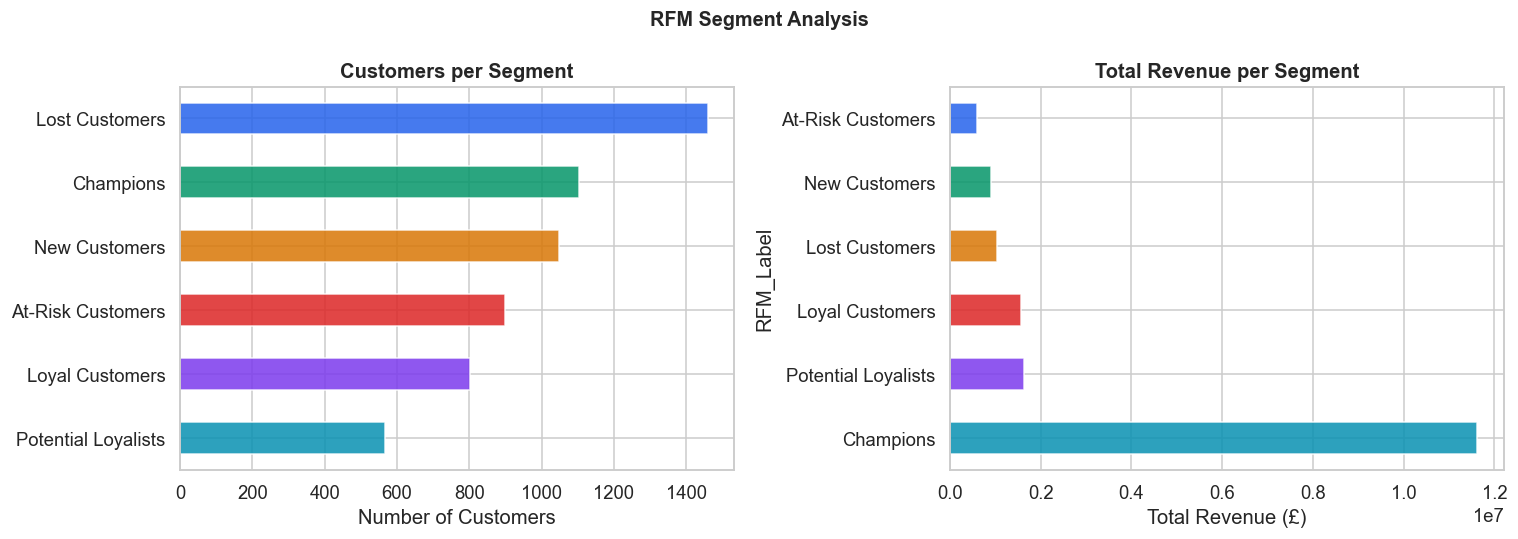

In [14]:
# Manual segment labels based on RFM scores
def label_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 2 and f >= 2:
        return 'Potential Loyalists'
    elif r >= 3 and f == 1:
        return 'New Customers'
    elif r == 2 and f <= 2:
        return 'At-Risk Customers'
    else:
        return 'Lost Customers'

rfm['RFM_Label'] = rfm.apply(label_segment, axis=1)

segment_counts = rfm['RFM_Label'].value_counts()
print('=== RFM Segment Counts ===')
print(segment_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [BLUE, GREEN, ORANGE, RED, PURPLE, '#0891b2']
segment_counts.plot(kind='barh', ax=axes[0],
                    color=colors[:len(segment_counts)], alpha=0.85)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].invert_yaxis()

# Revenue per segment
segment_rev = rfm.groupby('RFM_Label')['Monetary'].sum().sort_values(ascending=True)
segment_rev.plot(kind='barh', ax=axes[1],
                 color=colors[:len(segment_rev)], alpha=0.85)
axes[1].set_title('Total Revenue per Segment', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].invert_yaxis()

plt.suptitle('RFM Segment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Scale Features

Scaled features shape: (5878, 3)
Mean after scaling:    [-0.  0.  0.]
Std after scaling:     [1. 1. 1.]


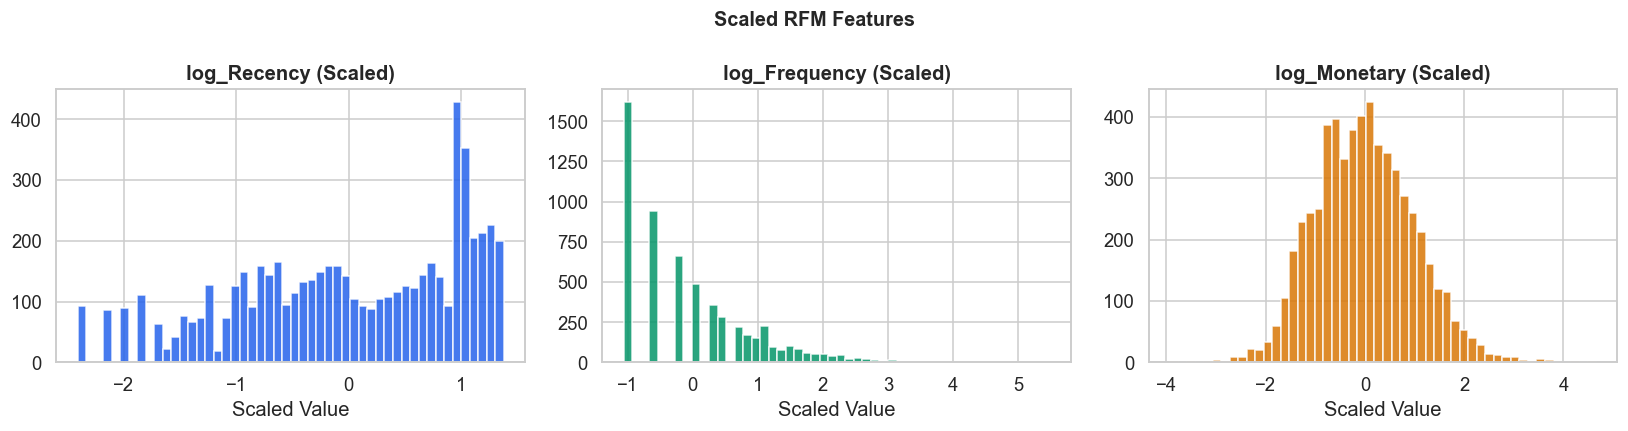

In [15]:
FEATURE_COLS = ['log_Recency', 'log_Frequency', 'log_Monetary']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[FEATURE_COLS])

print(f'Scaled features shape: {X_scaled.shape}')
print(f'Mean after scaling:    {X_scaled.mean(axis=0).round(4)}')
print(f'Std after scaling:     {X_scaled.std(axis=0).round(4)}')

# Visualise scaled features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = [BLUE, GREEN, ORANGE]
for i, (col, color) in enumerate(zip(FEATURE_COLS, colors)):
    axes[i].hist(X_scaled[:, i], bins=50, color=color, alpha=0.85)
    axes[i].set_title(f'{col} (Scaled)', fontweight='bold')
    axes[i].set_xlabel('Scaled Value')

plt.suptitle('Scaled RFM Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Save Processed Data

In [16]:
import joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save RFM features
rfm.to_csv('../data/processed/rfm_features.csv', index=False)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature column names
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump({'feature_cols': FEATURE_COLS}, f, indent=2)

print('Saved:')
print('  data/processed/rfm_features.csv')
print('  models/scaler.pkl')
print('  models/feature_cols.json')
print(f'\nRFM features shape: {rfm.shape}')
print(f'Columns: {list(rfm.columns)}')

Saved:
  data/processed/rfm_features.csv
  models/scaler.pkl
  models/feature_cols.json

RFM features shape: (5878, 13)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'log_Recency', 'log_Frequency', 'log_Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'RFM_Label']


In [ ]:
print("""
=================================================================
             FEATURE ENGINEERING SUMMARY
=================================================================

  RFM FEATURES COMPUTED
  - Recency   : days since last purchase
  - Frequency : number of unique invoices
  - Monetary  : total revenue generated

  TRANSFORMATIONS APPLIED
  - Log transform (log1p) to reduce right skewness
  - StandardScaler to normalise for clustering

  RFM SCORES
  - Quartile scores 1-4 assigned per dimension
  - Manual segment labels derived from score combinations
  - Total RFM Score range: 3 (worst) to 12 (best)

  NEXT STEP -> 03_modeling.ipynb
  - Elbow curve to find optimal K
  - Silhouette analysis
  - K-Means clustering
  - DBSCAN comparison
  - Cluster profiling and business interpretation
=================================================================
""")